# RAG 2/Langgraph
`12_langgraph_rag.ipynb`

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
# pip install beautifulsoup4

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
from pprint import pprint

# 1. Loader (웹문서)
from langchain_community.document_loaders import WebBaseLoader
from bs4.filter import SoupStrainer  # pip install beautifulsoup4

loader = WebBaseLoader(
    # 문서 출처 URL
    web_paths=('https://lilianweng.github.io/posts/2023-06-23-agent/', ),
    # 웹페이지 안에서 필요한 정보만 선택
    bs_kwargs={
        'parse_only': SoupStrainer(class_=['post-content']) 
    }
    # header_template={}
)
docs = loader.load()

# 2. Splitter
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
splitted_docs = splitter.split_documents(docs)
print(len(splitted_docs))

# 3. Embedding Model
from langchain_openai import OpenAIEmbeddings
embedding = OpenAIEmbeddings(model='text-embedding-3-small')  # small <-> large

# 4. Vectorstore (지금은 FAISS -> 클라우드-Pinecone)
from langchain_community.vectorstores import FAISS

vectorstore = FAISS.from_documents(splitted_docs, embedding=embedding)

63


In [4]:
from langchain import hub

prompt = hub.pull('rlm/rag-prompt')

for m in prompt.messages:
    m.pretty_print()

================================ Human Message =================================

You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
Question: {question} 
Context: {context} 
Answer:


In [ ]:
# LLM
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model='gpt-4.1', temperature=0)

# State
from langchain_core.documents import Document
from typing_extensions import TypedDict, List

class State(TypedDict):
    question: str
    context: List[Document]
    answer: str

# Node
# 검색 노드
def retrieve(state: State):
    # [ Document * 4 ]
    retrieved_docs = vectorstore.similarity_search(state['question'], k=4)

    # 나머지 return 하지 않은 state 항목들은, 알아서 그대로 감 (question, answer 는 알아서 그대로 나감)
    return { 'context': retrieved_docs, }


# 답변 생성노드
def generate(state: State):
    # Document 객체의 필요없는 정보는 다 빼고, 내용에 해당하는 page_content 만 모아서 넘기면 토큰 절약 가능.
    context_str = ''
    for doc in state['context']:
        context_str += doc.page_content + '\n------------------------\n'
    
    question_with_context = prompt.invoke({'question': state['question'], 'context': context_str})
    response = llm.invoke(question_with_context)
    return {'answer': response.content}

# Graph
from langgraph.graph import StateGraph, START, END
builder = StateGraph(State)

builder.add_node('retrieve', retrieve)
builder.add_node('generate', generate)

builder.add_edge(START, 'retrieve')
builder.add_edge('retrieve', 'generate')
builder.add_edge('generate', END)

graph = builder.compile()

# 출력
# from IPython.display import Image, display

# display(Image(graph.get_graph().draw_mermaid_png()))

In [9]:
final_state = graph.invoke({'question': '에이전트 시스템에 대해 알려줘!'})

final_state['answer']


'에이전트 시스템은 주어진 목표를 달성하기 위해 자율적으로 행동하고, 외부 자원(예: 인터넷, 파일, 메모리 등)을 활용하며, 작업을 분해하거나 다른 에이전트에게 위임할 수 있는 시스템입니다. 이러한 시스템은 자신의 행동을 지속적으로 평가하고, 과거 결정을 반성하여 효율적으로 문제를 해결합니다. 예를 들어, GPT 기반 에이전트는 검색, 정보 저장, 파일 출력 등 다양한 리소스를 활용해 복잡한 작업을 자동화할 수 있습니다.'

In [11]:
for event in graph.stream({'question': 'LangGraph가 뭐야?'}) :
    for node_name, output in event.items():
        print(f"[{node_name}] {output}")

[retrieve] {'context': '(4) Response generation: LLM receives the execution results and provides summarized results to users.\nTo put HuggingGPT into real world usage, a couple challenges need to solve: (1) Efficiency improvement is needed as both LLM inference rounds and interactions with other models slow down the process; (2) It relies on a long context window to communicate over complicated task content; (3) Stability improvement of LLM outputs and external model services.\n------------------------\nIllustration of how HuggingGPT works. (Image source: Shen et al. 2023)\n\nThe system comprises of 4 stages:\n(1) Task planning: LLM works as the brain and parses the user requests into multiple tasks. There are four attributes associated with each task: task type, ID, dependencies, and arguments. They use few-shot examples to guide LLM to do task parsing and planning.\nInstruction:\n------------------------\nBuilding agents with LLM (large language model) as its core controller is a coo

#### 메세지 스트리밍

In [12]:
for message, metadata in graph.stream(
    {"question": "What is Task Decomposition? 한국어로 답해줘"}, stream_mode="messages"
):
    print(message.content, end="")

Task Decomposition(작업 분해)는 복잡한 큰 작업을 더 작고 단순한 여러 단계나 하위 목표로 나누는 과정입니다. 이렇게 하면 각 단계를 차례로 해결하여 전체 작업을 효율적으로 수행할 수 있습니다. 예를 들어, "소설 쓰기"라는 큰 작업을 "줄거리 작성", "등장인물 설정" 등으로 나누는 것이 작업 분해입니다.

## RAG + a
- Metadata 편집
- Query 분석 - 보완

In [16]:
# 메타데이터 편집

# 문서 63개 중 1/3 지점
third = len(splitted_docs) // 3

for idx, doc in enumerate(splitted_docs):
    if idx < third:
        doc.metadata['section'] = 'beginning'
    elif idx < third * 2:
        doc.metadata['section'] = 'middle'
    else:
        doc.metadata['section'] = 'end'

splitted_docs[0].metadata

vectorstore = FAISS.from_documents(splitted_docs, embedding=embedding)

In [17]:
# State를 더 빡빡하게 정희하기 위해 위에 따로 정의한 클래스 Search

from typing import Literal  # 말 그대로
from typing_extensions import Annotated  # 할말이 좀 더 있다

class Search(TypedDict):  # StructuredOutput 에서 사용하기 위함
    """Vectorstore Search Query"""
    # 1. 타입, 2. ... -> NOT NULL, 3. 설명
    query: Annotated[str, ..., 'Search query to run']
    section: Annotated[
        Literal['beginning', 'middle', 'end'],
        ...,
        'Section to query'
    ]

class MyState(TypedDict):
    question: str
    query: Search 
    context: List[Document]
    answer: str

In [18]:
# Node
def analyze_query(state: MyState):
    # Search 클래스에 맞춰 사용자 question 을 {query, section}로 바꿈
    s_llm = llm.with_structured_output(Search)
    query = s_llm.invoke(state['question'])
    return {'query': query}

def retrieve(state: MyState):
    query = state['query']
    docs = vectorstore.similarity_search(
        query['query'],
        # LLM이 판단한 section 과 실제 문서조각의 section이 맞을 경우에만 검색.
        filter=lambda metadata: metadata.get('section') == query['section'],
    )
    return {'context': docs}

def generate(state: MyState):
    # Token 아끼기 위해, 내용만 추려서 문자열로 만들기
    doc_str = ''
    for doc in state['context']:
        doc_str += doc.page_content + '\n=====================\n'
    
    question_with_context = prompt.invoke({'question': state['question'], 'context': doc_str})
    res = llm.invoke(question_with_context)
    return {'answer': res.content}


builder = StateGraph(MyState)
builder.add_node('analyze_query', analyze_query)
builder.add_node('retrieve', retrieve)
builder.add_node('generate', generate)

builder.add_edge(START, 'analyze_query')
builder.add_edge('analyze_query', 'retrieve')
builder.add_edge('retrieve', 'generate')
builder.add_edge('generate', END)

graph = builder.compile()

In [19]:
graph.invoke({'question': '작업분배 뭐냐'})

{'question': '작업분배 뭐냐',
 'query': {'query': '작업분배란 무엇인가', 'section': 'beginning'},
 'context': [Document(id='8d8172c8-8bcd-45e6-8826-37e1535564db', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'section': 'beginning'}, page_content='Task decomposition can be done (1) by LLM with simple prompting like "Steps for XYZ.\\n1.", "What are the subgoals for achieving XYZ?", (2) by using task-specific instructions; e.g. "Write a story outline." for writing a novel, or (3) with human inputs.\nAnother quite distinct approach, LLM+P (Liu et al. 2023), involves relying on an external classical planner to do long-horizon planning. This approach utilizes the Planning Domain Definition Language (PDDL) as an intermediate interface to describe the planning problem. In this process, LLM (1) translates the problem into “Problem PDDL”, then (2) requests a classical planner to generate a PDDL plan based on an existing “Domain PDDL”, and finally (3) translates the PDDL plan back

## 9/9 대화형 RAG

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
# pip install -q langchain-pinecone

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from langchain_community.document_loaders import WebBaseLoader
from bs4.filter import SoupStrainer  # pip install beautifulsoup4
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_pinecone import PineconeVectorStore

from dotenv import load_dotenv
load_dotenv()

loader = WebBaseLoader(
    web_paths=('https://lilianweng.github.io/posts/2023-06-23-agent/', ),
    bs_kwargs={
        'parse_only': SoupStrainer(class_=['post-content']) 
    }
)
docs = loader.load()

splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
splitted_docs = splitter.split_documents(docs)

embedding = OpenAIEmbeddings(model='text-embedding-3-small')  # small <-> large

index_name = 'testing'

# pc = Pinecone()

# if pc.has_index(index_name):
#     index = pc.Index(index_name)
#     vectorstore = PineconeVectorStore(index=index, embedding=embedding)
# else:
#     print('No index name', index_name)

# 위에 코드대로 해도 되지만 아래 코드가 짧고 간결함
# 아래 코드 1회 실행하면 실제 데이터가 들어가서 영구 저장됨(2번 X)
# -----------------------------
# vectorstore = PineconeVectorStore.from_documents(
#     splitted_docs,
#     index_name=index_name,
#     embedding=embedding
# )

In [20]:
# (2회 실행)기존에 존재하는 index를 불러오는 코드
index_name = 'testing'
vectorstore = PineconeVectorStore.from_existing_index(index_name=index_name, embedding=embedding)

In [3]:
from langchain_core.tools import tool

@tool(response_format='content_and_artifact')  # 2개를 return 한다
def retrieve(query: str):
    """Retrieve information related to a query
    Args:
        query : Query to search
    """
    # 원본 Document list (artifact)
    docs = vectorstore.similarity_search(query, k=3)
    # 편집한 텍스트 (content)
    result_text = '\n\n'.join(
        (f'Source: {doc.metadata}\nContent: {doc.page_content}')
        for doc in docs
    )
    return result_text, docs

In [4]:
from langchain_openai import ChatOpenAI
from langgraph.graph import MessagesState
from langchain_core.messages import SystemMessage
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph import START, END

llm = ChatOpenAI(model='gpt-4.1', temperature=0)

# Node
def query_or_respond(state: MessagesState):
    """도구 호출을 하거나, 최종 응답을 한다."""
    llm_with_tools = llm.bind_tools([retrieve])
    res = llm_with_tools.invoke(state['messages'])
    return {'messages': [res]}

tools = ToolNode([retrieve])

def generate(state: MessagesState):
    """응답 생성"""
    tool_messages = []
    for msg in reversed(state['messages']):  # 메세지 목록을 뒤집음: 최신 메세지부터 순회
        if msg.type == 'tool':
            tool_messages.append(msg)
        else:
            break
    tool_messages.reverse()
    docs_content = '\n\n'.join(doc.content for doc in tool_messages)
    system_message_content = (
        "You are an assistant for question-answering tasks. "
        "Use the following pieces of retrieved context to answer "
        "the question. If you don't know the answer, say that you "
        "don't know. Use three sentences maximum and keep the "
        "answer concise."
        "\n\n"
        f"{docs_content}"
    )
    # 필요 없는 Tool 메세지들을 제외하고, AI, Human, System 메시지만 모아서 정리
    conversation_messages = [
        message
        for message in state["messages"]
        if message.type in ("human", "system")
        or (message.type == "ai" and not message.tool_calls)
    ]
    prompt = [SystemMessage(system_message_content)] + conversation_messages

    # Run
    response = llm.invoke(prompt)
    return {"messages": [response]}

In [5]:
from langgraph.graph import MessagesState, StateGraph

builder = StateGraph(MessagesState) # 'messages'

# builder.add_node('query_or_respond', query_or_respond)  # 아래와 같은 결과
builder.add_node(query_or_respond)
builder.add_node(tools)
builder.add_node(generate)

# builder.set_entry_point('query_or_respond')  # 아래와 같은 말
builder.add_edge(START, 'query_or_respond')
builder.add_conditional_edges(
    'query_or_respond',
    tools_condition,
    {END: END, 'tools': 'tools'}  # 정확하게 상황별 다음 Node 를 지정할 수 있음
)
builder.add_edge('tools', 'generate')
builder.add_edge('generate', END)

graph = builder.compile()

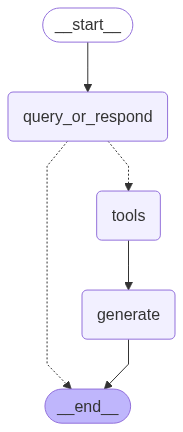

In [6]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [12]:
input_state = {
    'messages': [
        {'role': 'user', 'content': 'hello'}
    ]
}

res = graph.invoke(input_state)

for msg in res['messages']:
    msg.pretty_print()

================================ Human Message =================================

hello
================================== Ai Message ==================================

Hello! How can I help you today?


## 대화기록 저장하기(Langgraph Memory)

In [21]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

# 위에 정의된 builder 사용
graph = builder.compile(checkpointer=memory)

In [22]:
config = {
    'configurable': {'thread_id': '123'}
}

input_state = {
    'messages': [
        {'role': 'user', 'content': 'LLM Agent는 어떤 경우에 만드는게 좋아?'}
    ]
}

res = graph.invoke(input_state, config)

for msg in res['messages']:
    msg.pretty_print()

================================ Human Message =================================

LLM Agent는 어떤 경우에 만드는게 좋아?
================================== Ai Message ==================================

LLM Agent(대형 언어 모델 에이전트)는 다음과 같은 경우에 만드는 것이 좋습니다:

1. **복잡한 자동화가 필요할 때**  
   단순한 챗봇이나 Q&A 시스템이 아니라, 여러 단계의 의사결정, 외부 도구 연동, 데이터 수집·분석 등 복잡한 작업을 자동화해야 할 때 LLM Agent가 유용합니다.

2. **여러 시스템/도구와 연동해야 할 때**  
   예를 들어, 이메일, 캘린더, 데이터베이스, API 등 다양한 외부 서비스와 상호작용해야 하는 경우, LLM Agent가 각 도구를 연결하고 통합적으로 관리할 수 있습니다.

3. **상황에 따라 동적으로 행동을 바꿔야 할 때**  
   사용자의 요청이나 환경에 따라 적절한 행동(예: 정보 검색, 요약, 번역, 코드 실행 등)을 선택해야 하는 경우, LLM Agent가 스스로 판단하여 적합한 액션을 수행할 수 있습니다.

4. **지속적인 대화와 맥락 유지가 필요할 때**  
   단발성 응답이 아니라, 여러 차례의 대화에서 맥락을 기억하고, 그에 따라 적절히 대응해야 하는 경우 LLM Agent가 효과적입니다.

5. **복수의 역할(예: 비서, 분석가, 상담가 등)을 수행해야 할 때**  
   하나의 시스템이 다양한 역할을 수행해야 할 때, LLM Agent는 역할에 따라 행동 방식을 바꿀 수 있습니다.

### 예시 상황
- 고객 지원 챗봇이 단순 답변을 넘어서, 주문 조회, 환불 처리, 배송 추적 등 다양한 업무를 자동으로 처리해야 할 때
- 연구 논문 요약, 데이터 분석, 보고서 작성 등 복합적인 지식 작업을 자동화하고 싶을 때
- 사용자의 일정 관리,